In [1]:
! pip install nltk
! pip install vaderSentiment
! pip install pytrends
! pip install textblob
! pip install wordcloud
! pip install gensim
! pip install seaborn
! pip install TextBlob
! pip install joblib

In [2]:
import nltk
import logging
import numpy as np
import pandas as pd
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.preprocessing import LabelEncoder


from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import joblib
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [3]:
# Download NLTK resources (if not already downloaded)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('wordnet', quiet=True)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\apoor\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\apoor\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\apoor\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
df = pd.read_csv('Dataset/Cleaned_Data/reviews.csv')
df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments,cleaned_comments,polarity,sentiment
0,2818.0,1191.0,2009-03-30,10952,Lam,Daniel is really cool. The place was nice and ...,daniel is really cool. the place was nice and ...,0.140741,neutral
1,515749.0,1671407.0,2012-07-09,2640670,Gregory,If you want the authentic Amsterdam houseboat ...,if you want the authentic amsterdam houseboat ...,0.285738,neutral
2,515749.0,1715674.0,2012-07-15,1032804,Michael,Unique and luxurious to be sure. I couldn't re...,unique and luxurious to be sure. i couldn't re...,0.287078,neutral
3,2818.0,1771.0,2009-04-24,12798,Alice,Daniel is the most amazing host! His place is ...,daniel is the most amazing host! his place is ...,0.365278,positive
4,515749.0,1963378.0,2012-08-12,503786,Brian,My wife and I recently stopped in Amsterdam fo...,my wife and i recently stopped in amsterdam fo...,0.172183,neutral


Date Preprocessing

In [5]:
df.isnull().sum()

listing_id          0
id                  0
date                0
reviewer_id         0
reviewer_name       0
comments            0
cleaned_comments    3
polarity            0
sentiment           0
dtype: int64

In [6]:
# Dropping the null values
df.dropna(inplace=True)
df.isnull().sum()

listing_id          0
id                  0
date                0
reviewer_id         0
reviewer_name       0
comments            0
cleaned_comments    0
polarity            0
sentiment           0
dtype: int64

Exploratory Data Analysis

In [7]:
reviewer_freq = df['reviewer_name'].value_counts()
print(reviewer_freq)

David               2312
Michael             2025
Sarah               1864
Daniel              1820
Laura               1811
                    ... 
Daniella And Max       1
Szabó                  1
Hanim                  1
Wycher                 1
Tos                    1
Name: reviewer_name, Length: 47584, dtype: int64


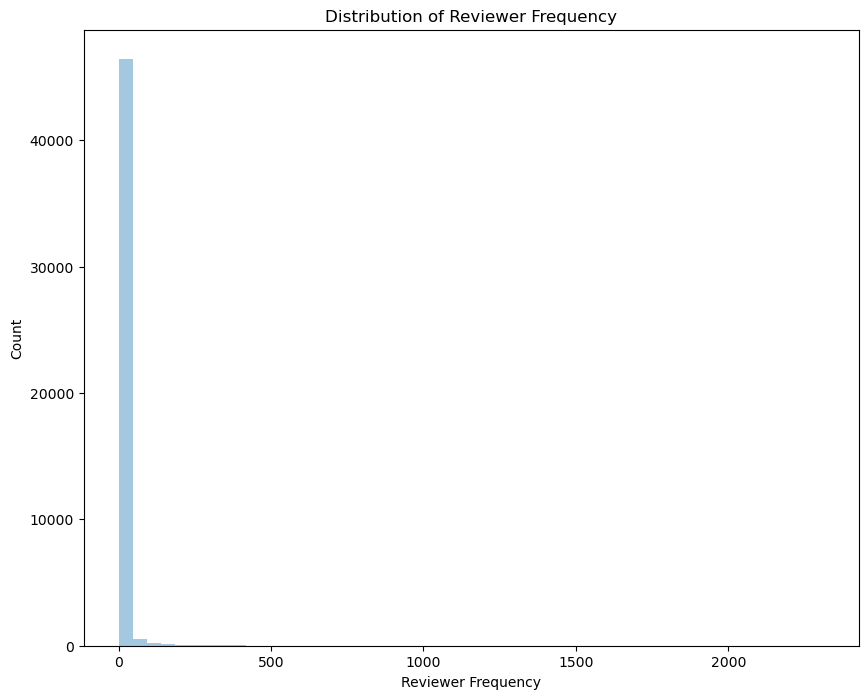

In [8]:
# plot the distribution of reviewer frequency using seaborn
plt.figure(figsize=(10, 8))
sns.distplot(reviewer_freq, kde=False)
plt.title('Distribution of Reviewer Frequency')
plt.xlabel('Reviewer Frequency')
plt.ylabel('Count')
plt.show()

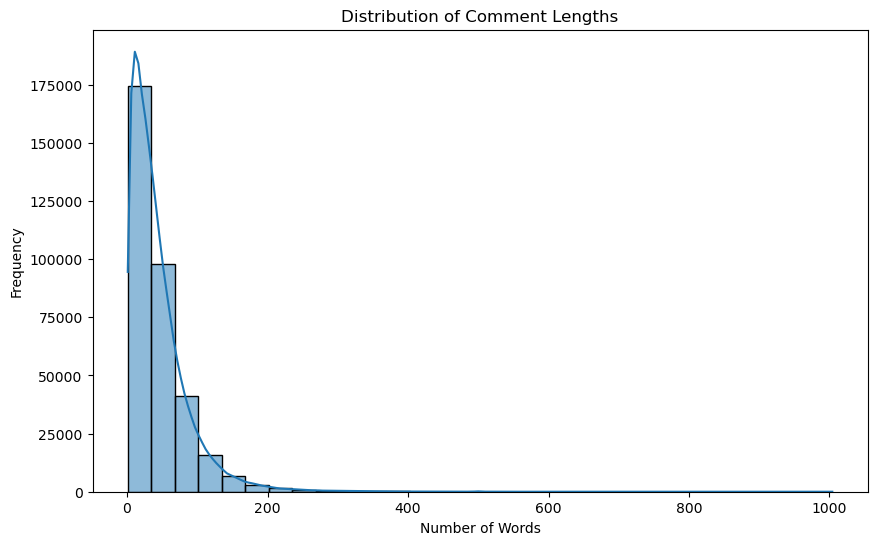

In [9]:
df['comment_length'] = df['cleaned_comments'].apply(lambda x: len(x.split()))
plt.figure(figsize=(10, 6))
sns.histplot(df['comment_length'], bins=30, kde=True)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.show()

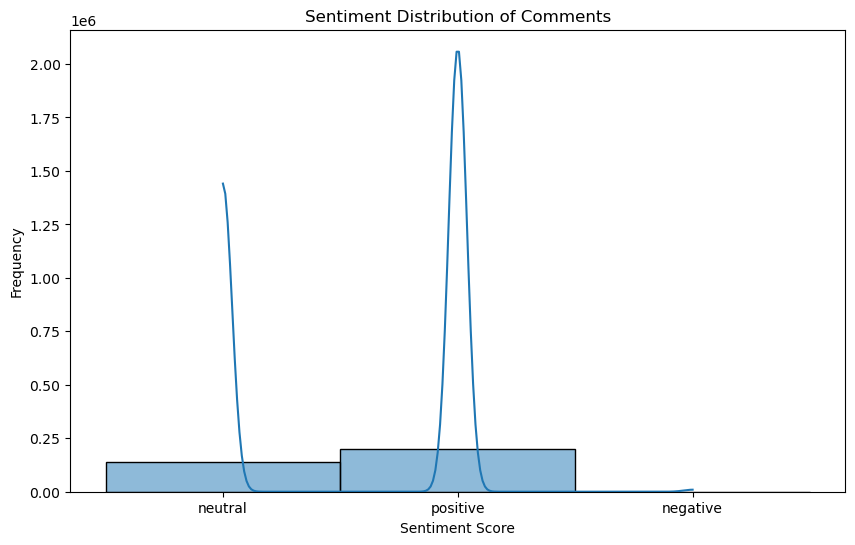

In [10]:
# Visualizing Sentiment Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['sentiment'], bins=30, kde=True)
plt.title('Sentiment Distribution of Comments')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

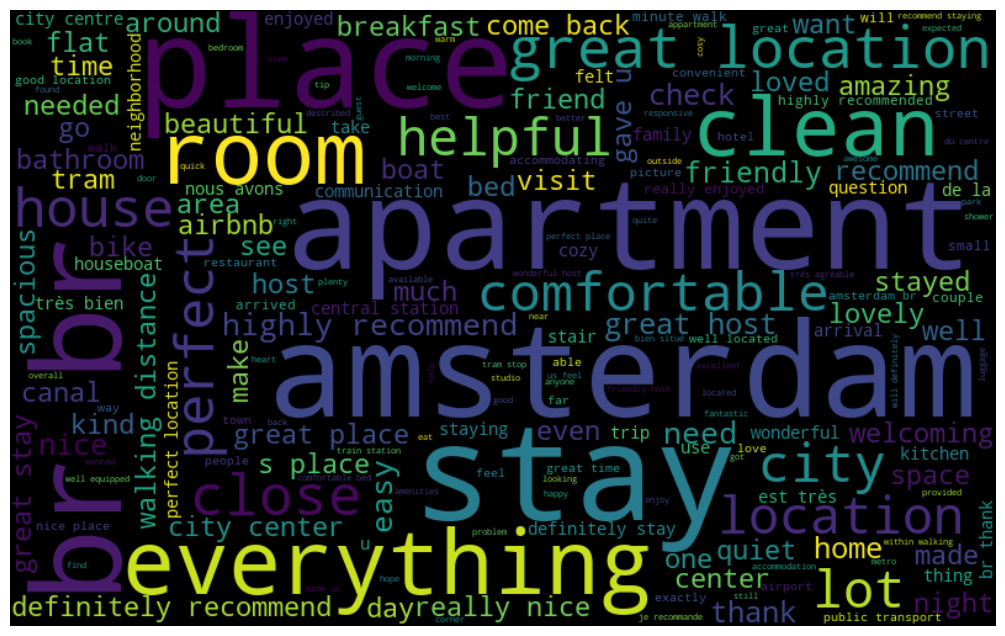

In [11]:
# Word Frequency Analysis
all_words = ' '.join([text for text in df['cleaned_comments']])
wordcloud = WordCloud(width=800, height=500, random_state=21,
                      max_font_size=110).generate(all_words)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

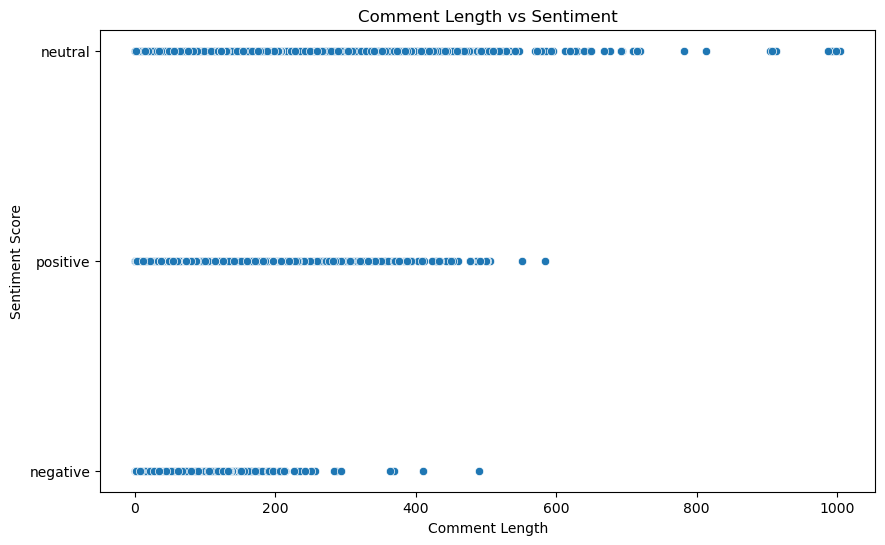

In [12]:
# Comment Length vs Sentiment
plt.figure(figsize=(10, 6))
sns.scatterplot(x='comment_length', y='sentiment', data=df)
plt.title('Comment Length vs Sentiment')
plt.xlabel('Comment Length')
plt.ylabel('Sentiment Score')
plt.show()

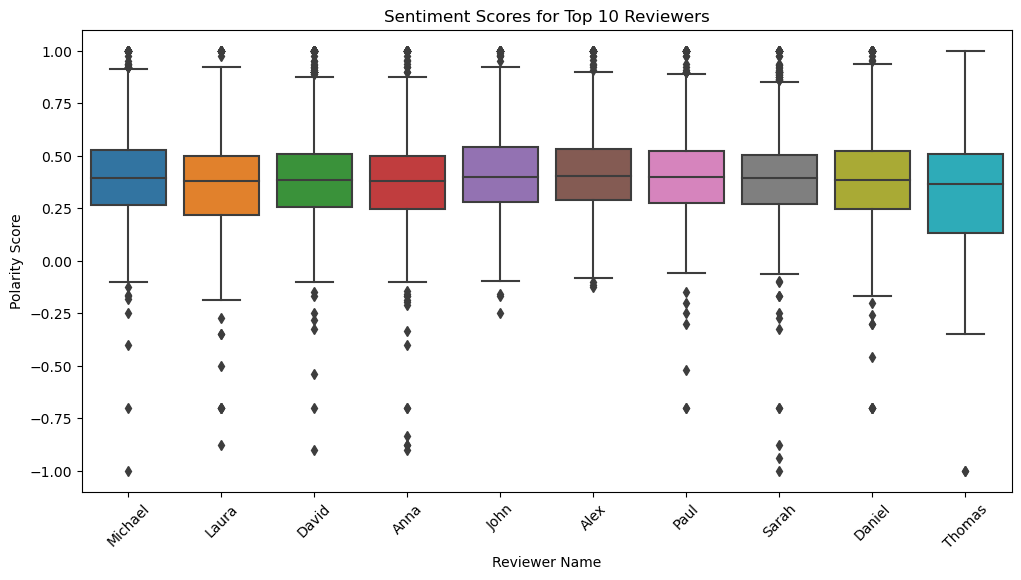

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='reviewer_name', y='polarity', data=top_reviewers_df)
plt.xticks(rotation=45)
plt.title('Sentiment Scores for Top 10 Reviewers')
plt.xlabel('Reviewer Name')
plt.ylabel('Polarity Score')
plt.show()

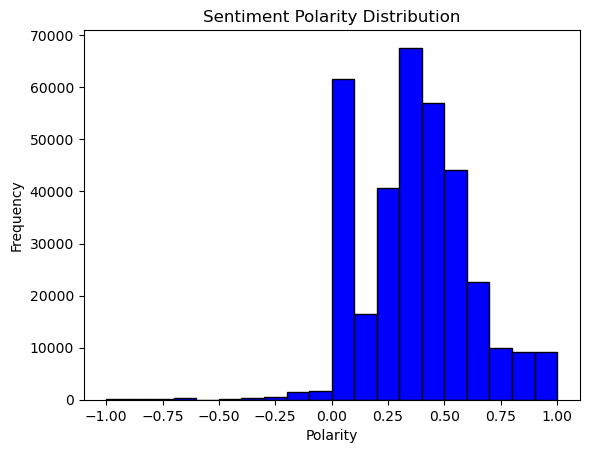

In [15]:
# Plot histogram
plt.hist(df['polarity'], bins=20, color='blue', edgecolor='black')
plt.title('Sentiment Polarity Distribution')
plt.xlabel('Polarity')
plt.ylabel('Frequency')
plt.show()

Assessment: Experimentations (using Machine Learning)

In [17]:
# Vectorization
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df['cleaned_comments'])

In [18]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, df['sentiment'], test_size=0.2, random_state=42)

In [19]:
print("Features X_train:")
X_train

Features X_train:


<274309x150039 sparse matrix of type '<class 'numpy.float64'>'
	with 9369713 stored elements in Compressed Sparse Row format>

In [20]:
print("Features X_test:")
X_test

Features X_test:


<68578x150039 sparse matrix of type '<class 'numpy.float64'>'
	with 2336206 stored elements in Compressed Sparse Row format>

In [21]:
print("Features y_train:")
y_train

Features y_train:


186384    positive
258748    positive
239269    positive
19436     positive
116901    positive
            ...   
119879    positive
259180    positive
131933     neutral
146868     neutral
121958    positive
Name: sentiment, Length: 274309, dtype: object

In [22]:
print("Features y_test:")
y_test

Features y_test:


245127    positive
107988    positive
549        neutral
258122     neutral
50770      neutral
            ...   
189476     neutral
126286    positive
231064    positive
53132     positive
54839     positive
Name: sentiment, Length: 68578, dtype: object

1. Logistic Regression

In [23]:
print("Evaluation for: Logistic Regression Classifier".center(80, '_'))

lgc = LogisticRegression()
lgc.fit(X_train, y_train)

lgc_pred = lgc.predict(X_test)
lgc_acc = accuracy_score(y_test, lgc_pred)
lgc_prec = precision_score(y_test, lgc_pred, average='weighted')
lgc_rec = recall_score(y_test, lgc_pred, average='weighted')
lgc_f1 = f1_score(y_test, lgc_pred, average='weighted')

print(f"Model Type: {lgc}")
print("\n" + f"Prediciton: {lgc_pred}")
print('-' * 80)

print(f"Accuracy Score:  {(lgc_acc):%}")
print(f"Precision Score: {(lgc_prec):%}")
print(f"Recall Score:    {(lgc_rec):%}")
print(f"F1-Score:        {(lgc_f1):%}")

_________________Evaluation for: Logistic Regression Classifier_________________
Model Type: LogisticRegression()

Prediciton: ['positive' 'positive' 'neutral' ... 'positive' 'positive' 'positive']
--------------------------------------------------------------------------------
Accuracy Score:  91.727668%
Precision Score: 91.725426%
Recall Score:    91.727668%
F1-Score:        91.649631%


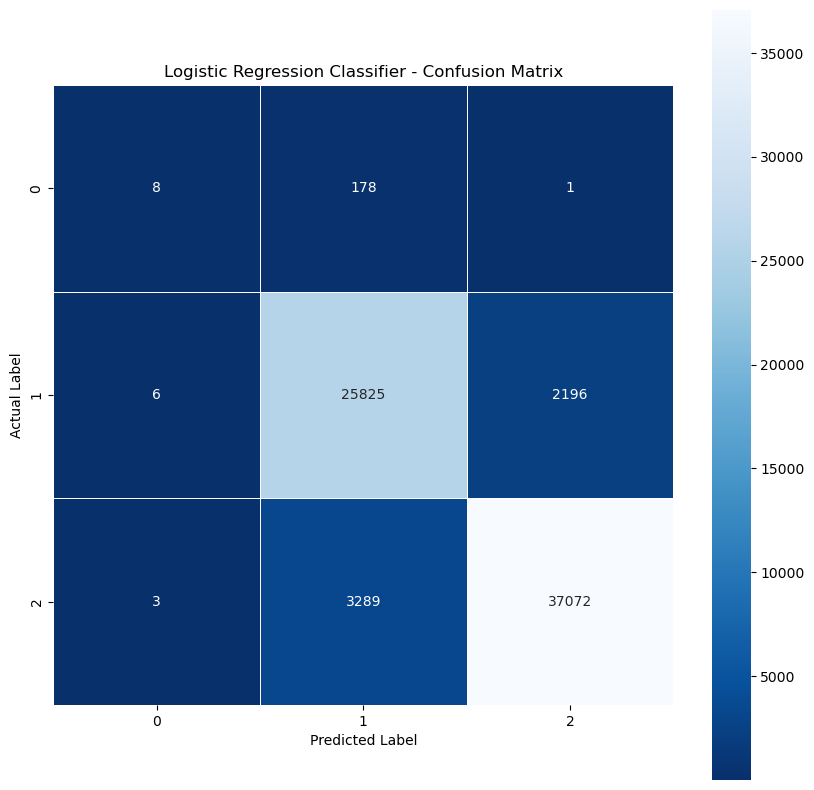

In [24]:
# Plotting the Confusion Matrix:
lgc_confusion_matrix = confusion_matrix(y_test, lgc_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(lgc_confusion_matrix, annot=True, fmt=".0f",
            linewidths=0.7, square=True, cmap="Blues_r")
plt.ylabel("Actual Label")
plt.xlabel("Predicted Label")
plt.title("Logistic Regression Classifier - Confusion Matrix")
plt.show()

In [25]:
print("Classification Report For Logistic Regression Classifier:")
print('-' * 57)
print(classification_report(y_test, lgc_pred))

Classification Report For Logistic Regression Classifier:
---------------------------------------------------------
              precision    recall  f1-score   support

    negative       0.47      0.04      0.08       187
     neutral       0.88      0.92      0.90     28027
    positive       0.94      0.92      0.93     40364

    accuracy                           0.92     68578
   macro avg       0.77      0.63      0.64     68578
weighted avg       0.92      0.92      0.92     68578



In [27]:
# save the logistic regression model
joblib.dump(lgc, 'Models/logistic_regression_model.pkl')

['Models/logistic_regression_model.pkl']

In [28]:
# save the vectorizer
joblib.dump(vectorizer, 'Models/tfidf_vectorizer.pkl')

['Models/tfidf_vectorizer.pkl']